In [40]:
import pdf2image  # PyMuPDF
import pytesseract
import cv2
import numpy as np
from PIL import Image
from pathlib import Path
import re
import json
import matplotlib.pyplot as plt

In [78]:
pytesseract.pytesseract.tesseract_cmd = r"C:/Program Files/Tesseract-OCR/tesseract.exe"

pdf_path = Path("normal_test.pdf")

doc = pdf2image.convert_from_path(pdf_path) #creates list object 

#width 1700, length 2200

pil_image = doc[0]
cv2_image = np.array(pil_image)


In [79]:
height, width, _ = cv2_image.shape

print (height, width)

2200 1700


In [ ]:
type_start_point = (920, 330)
type_end_point = (1300, 480)

x1 = min(type_start_point[0], type_end_point[0])
x2 = max(type_start_point[0], type_end_point[0])
y1 = min(type_start_point[1], type_end_point[1])
y2 = max(type_start_point[1], type_end_point[1])

text = None
cv2_image = cv2.cvtColor(np.array(cv2_image), cv2.COLOR_RGB2BGR)
roi = cv2_image[y1:y2, x1:x2] #initial box for type of facility
blurred_image = cv2.GaussianBlur(roi, (5, 5), 0)
edges = cv2.Canny(blurred_image, 50, 150) #get contoured polygons
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for contour in contours:
    approx = cv2.approxPolyDP(contour, 0.04 * cv2.arcLength(contour, True), True) #get polgyon curve
    if len(approx) == 4 and cv2.isContourConvex(approx):
        x, y, w, h = cv2.boundingRect(approx)
        aspect_ratio = float(w) / h
        area = cv2.contourArea(approx) 
        if 0.85 <= aspect_ratio <= 1.15 and 500 <= area <= 5000: #check if its a box
            cropped_rect = roi[y : (y + h), x : (x + w)]
            gray_box = cv2.cvtColor(cropped_rect, cv2.COLOR_BGR2GRAY)
            _, binary = cv2.threshold(gray_box, 150, 255, cv2.THRESH_BINARY_INV)
            # Crop inside to ignore border (e.g. 10% margin)
            margin = int(min(w, h) * 0.1)
            inner = binary[margin:h-margin, margin:w-margin]
            fill_ratio = cv2.countNonZero(inner) / float(inner.size) #check how much is filled
            is_filled = fill_ratio > 0.2  # can adjust threashold
            print(f"Checkbox at ({x},{y}) - Filled: {is_filled}, Fill Ratio: {fill_ratio:.2f}")

            if is_filled:
                text_offset_x = 10  # pixels to skip after box
                text_width = 50    # width of text region to extract
                text_roi = roi[y:y+h, x+w+text_offset_x:x+w+text_offset_x+text_width]
                text_gray = cv2.cvtColor(text_roi, cv2.COLOR_BGR2GRAY)
                _, text_thresh = cv2.threshold(text_gray, 150, 255, cv2.THRESH_BINARY)
                text = pytesseract.image_to_string(text_thresh, config='--psm 6') #gets first letters of the phrase

print (text)

#test

#probably can eliminate one instance of grayscaling


Checkbox at (16,110) - Filled: False, Fill Ratio: 0.10
Checkbox at (16,71) - Filled: False, Fill Ratio: 0.12
Checkbox at (16,33) - Filled: True, Fill Ratio: 0.25
Cou



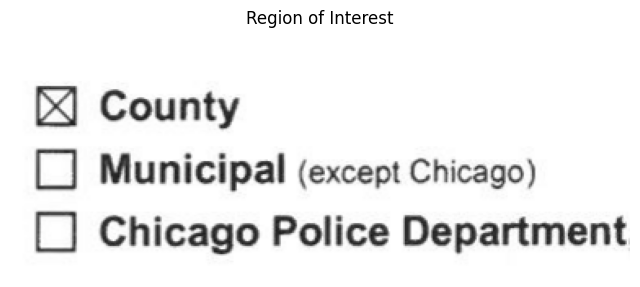

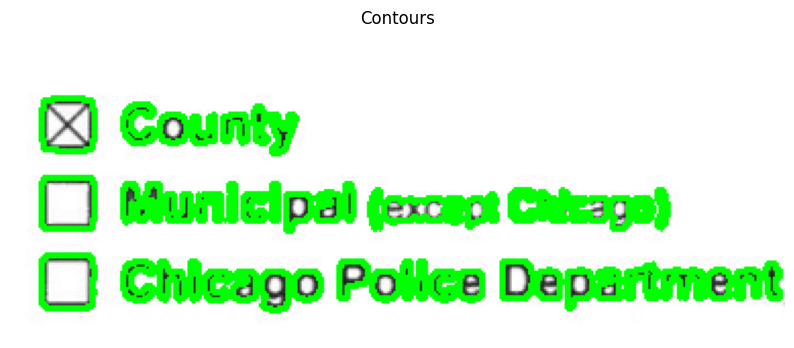

In [102]:
# Convert BGR to RGB for correct display with matplotlib
roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
image_with_contours = roi.copy()
cv2.drawContours(image_with_contours, contours, -1, (0, 255, 0), 2)
image_with_contours_rgb = cv2.cvtColor(image_with_contours, cv2.COLOR_BGR2RGB)

# Display ROI
plt.figure(figsize=(8, 4))
plt.title("Region of Interest")
plt.imshow(roi_rgb)
plt.axis('off')
plt.show()

# Display contours
plt.figure(figsize=(10, 6))
plt.title("Contours")
plt.imshow(image_with_contours_rgb)
plt.axis('off')
plt.show()

In [103]:
text = pytesseract.image_to_string(roi, lang="eng", config="--psm 6")
print (text)

&] County
(0 Municipal (except Chicago)
0 Chicago Police Department



Notes:
- Need to turn page to black and white, contrast
- Need to break into smaller sections
- Identify four corners of the document on an angled document, do a coordinate projection
- Define regions for model to do dvisions
- Turn image into array, do conversions with color, blur slightly (cv2)
- Read cv2 functions - Canny could find boxes to fill in
- For boxes ---> Look at average value of pixels inside
- Every page should a row in a tabular dataset

Sections to break up:
- County/Municipal/Chicago PD *
- Faciltiy Name
- Telephone #
- Address
- Date
- Time *
- Type of Occurence *
- Detainees Table
- Any Injuries *
- Any resulting death? *
- Other death/injury data?